# QPhenoCrops: NDVI Time Series Analysis for Temporary Agricultural Crops

**QPhenoCrops** is a tool developed to analyze vegetation dynamics for agricultural monitoring using Sentinel-2 satellite imagery.
It is designed for **temporary agricultural crops**, supporting applications across different cropping systems and regions, including the **Brazilian Cerrado biome**.

The workflow includes clipping Sentinel-2 bands B04 (red) and B08 (NIR) using a shapefile, calculating the **Normalized Difference Vegetation Index (NDVI)**, applying smoothing techniques (e.g., **Savitzky-Golay** or moving averages), and extracting key phenological metrics such as:
**Start of Season (SOS)**, **Peak of Season (POS)**, and **End of Season (EOS)**.

The results are visualized through NDVI time series plots, enabling the identification of crop development stages, growth dynamics, and senescence patterns, supporting agricultural monitoring and analysis.


## Install Required Packages

This cell installs the Python libraries required to run the **QPhenoCrops** workflow.

The main dependencies include:

- `geopandas`: for reading and processing vector data (e.g., shapefiles)  
- `pystac-client`: to search and interact with STAC catalogs  
- `planetary-computer`: for authenticated access to remote datasets  
- `rioxarray`, `rasterio`, `xarray`: for loading, clipping, and processing geospatial raster data  
- `matplotlib`: for visualizing NDVI time series and phenological metrics  
- `dask`: for parallel computing and efficient handling of large datasets  

Run the cell below if these packages are not already installed in your Python environment.

In [1]:
!pip install geopandas pystac-client planetary-computer rioxarray rasterio xarray matplotlib dask

## Import Libraries

This block imports the Python libraries required for the **QPhenoCrops workflow**, organized by functionality to improve readability and reproducibility.

### System and file handling
- `os`, `re`, and `collections.defaultdict` are used for file management, pattern matching, and efficient dictionary operations.

### Date and time
- `datetime` is used to handle temporal information and date-based processing.

### Geospatial processing
- `geopandas`, `rioxarray`, `pyproj`, and `shapely` (geometry and transformations) are used to handle vector and raster geospatial data, perform coordinate reference system transformations, and clip spatial datasets.

### Satellite data access (STAC)
- `pystac_client.Client` is used to access STAC catalogs.
- `planetary_computer` enables authenticated access to Microsoft Planetary Computer datasets.

### Data analysis and numerical processing
- `numpy` and `pandas` are used for numerical computations and tabular data handling.
- `scipy.signal.savgol_filter` is used for smoothing NDVI time series.

### Visualization
- `matplotlib.pyplot` is used to plot NDVI time series and phenological metrics.

### Networking and display
- `requests` is used for HTTP requests.
- `IPython.display.display` is used to render rich outputs in Jupyter notebooks.

In [2]:
import datetime
import os
import re
from collections import defaultdict

import geopandas as gpd
import planetary_computer
import pyproj  # For CRS transformations
import rioxarray as rxr
from shapely.geometry import mapping
from shapely.ops import transform  # For geometric reprojection
from pystac_client import Client

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import requests
from IPython.display import display


## Input Data and Shapefile Loading

This section defines the input dataset used in the workflow, including the vector shapefile that represents the study area.

The shapefile is loaded using GeoPandas and reprojected to the standard geographic coordinate reference system (EPSG:4326), ensuring compatibility with satellite data sources.

Key steps include:
- Loading the vector data from the input path  
- Reprojecting the dataset to EPSG:4326  
- Generating a unified geometry for spatial operations  
- Creating a list of individual geometries for raster clipping and further processing  
- Verifying the coordinate reference system (CRS) and geometry structure  

These steps ensure spatial consistency between vector and raster datasets used in subsequent analyses.

In [3]:
## INPUT DATA (REPLACE with your shapefile directory)
shapefile_path = "/Users/liviadias/Documents/liviadias/ARTIGO LIA/testes_BA/pivo_01.shp"

# Load shapefile and convert to EPSG:4326
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
geometry = mapping(gdf.geometry.union_all())
print("Shapefile loaded!")
print(f"Shapefile CRS: {gdf.crs}")
print(f"Shapefile geometries:\n{gdf.geometry}")

# List of geometries
geoms = list(gdf.geometry)

Shapefile loaded!
Shapefile CRS: EPSG:4326
Shapefile geometries:
0    POLYGON ((-45.56958 -12.92885, -45.57027 -12.9...
Name: geometry, dtype: geometry


## Search, Load, Clip Sentinel-2 Images and Compute NDVI

This code block implements the full workflow for retrieving and processing Sentinel-2 imagery from the Microsoft Planetary Computer to generate a time series of NDVI values.

### 1. Image search (STAC catalog)
The code connects to the STAC catalog and searches for Sentinel-2 Level 2A images that:
- Intersect the study area
- Fall within the defined time range
- Have less than 10% cloud cover

### 2. Filtering by acquisition date
Retrieved images are grouped by acquisition date.  
For each date, the image with the lowest cloud cover is selected to avoid duplicates and ensure data quality.

### 3. Data loading and preprocessing
For each selected image:
- The red (B04) and near-infrared (B08) bands are loaded using `rioxarray` with chunking for efficient processing.
- The shapefile geometry is reprojected if its CRS does not match the raster CRS.

### 4. Spatial clipping and NDVI computation
- The raster bands are clipped to the study area geometry.
- NDVI is calculated using the standard formula:
  (NIR - Red) / (NIR + Red)
- The mean NDVI value is extracted for each date.

### 5. Visualization and time series construction
- Optionally, NDVI rasters are plotted for visual inspection.
- Mean NDVI values and corresponding dates are stored in a structured time series.
- The final dataset is sorted chronologically and used for phenological analysis.

Images found: 29
Unique images selected per date: 29

Processing image from 2021-11-25
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.2046


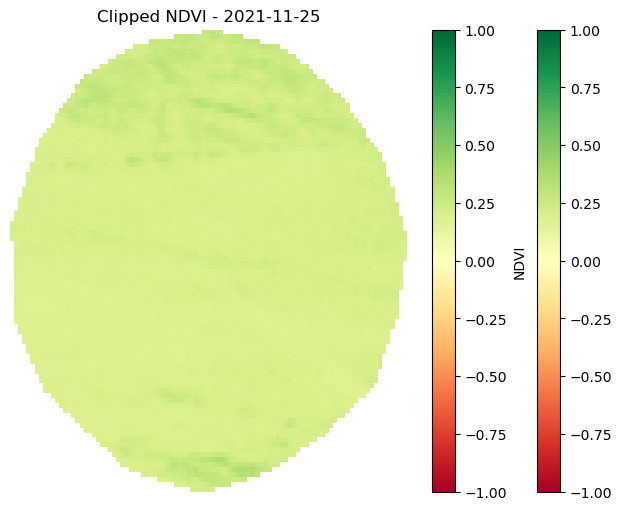


Processing image from 2021-10-06
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.2557


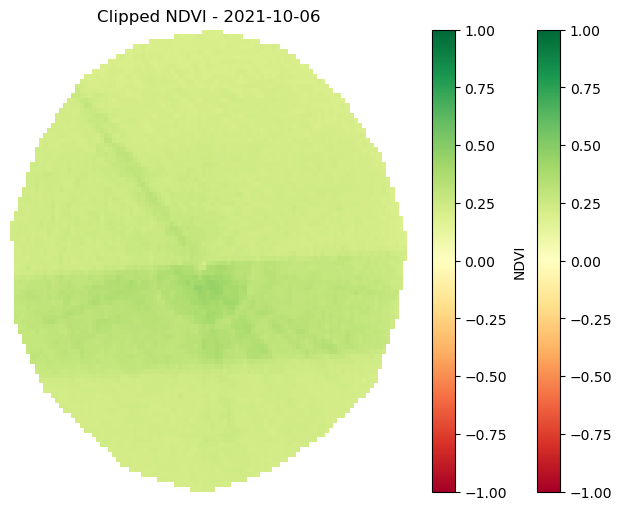


Processing image from 2021-10-01
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.2774


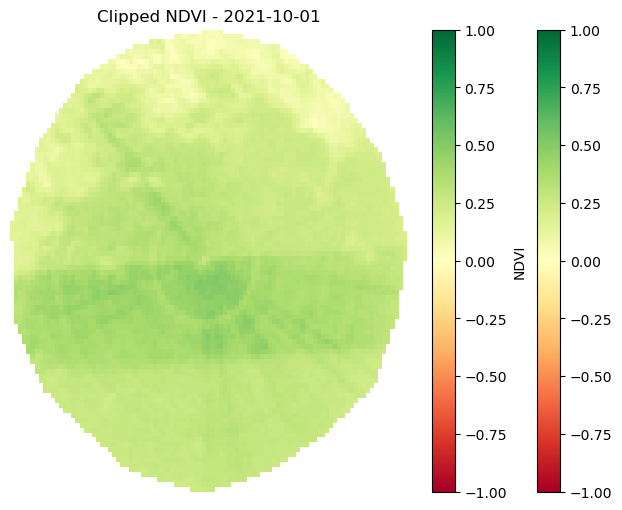


Processing image from 2021-09-26
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.4151


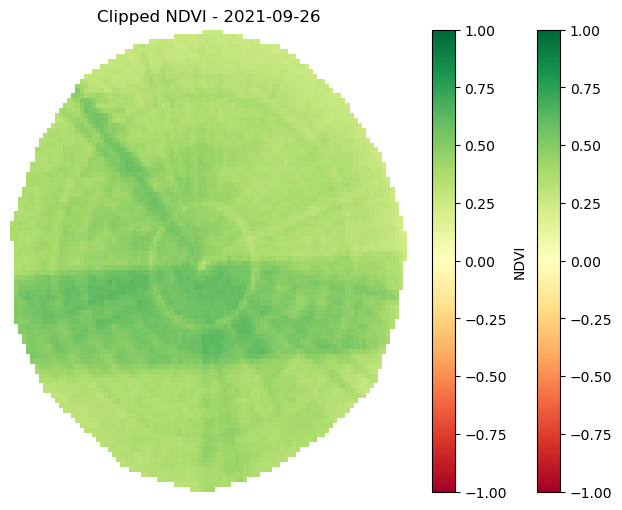


Processing image from 2021-09-21
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.5731


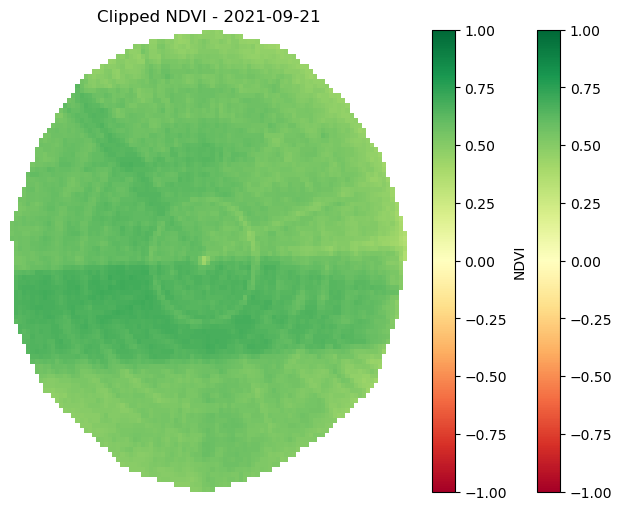


Processing image from 2021-09-16
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.7053


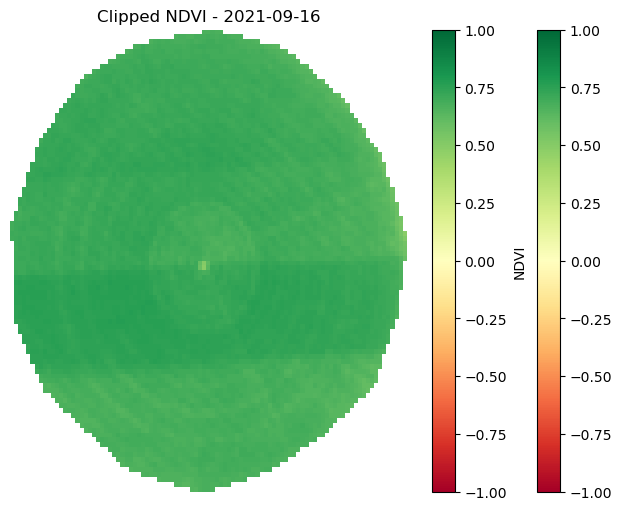


Processing image from 2021-09-11
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.7946


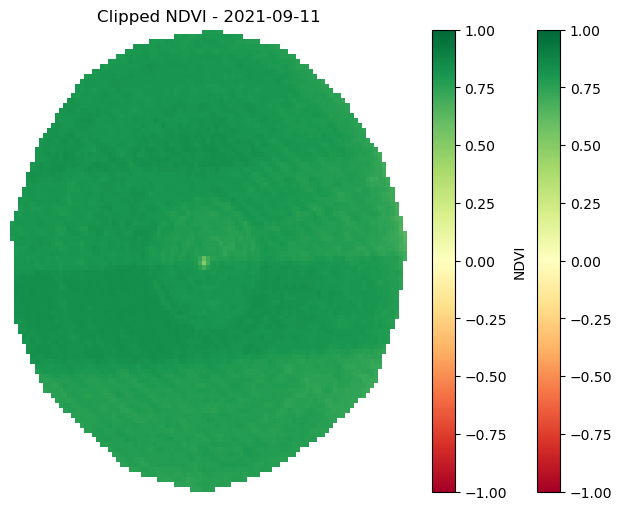


Processing image from 2021-09-06
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.8294


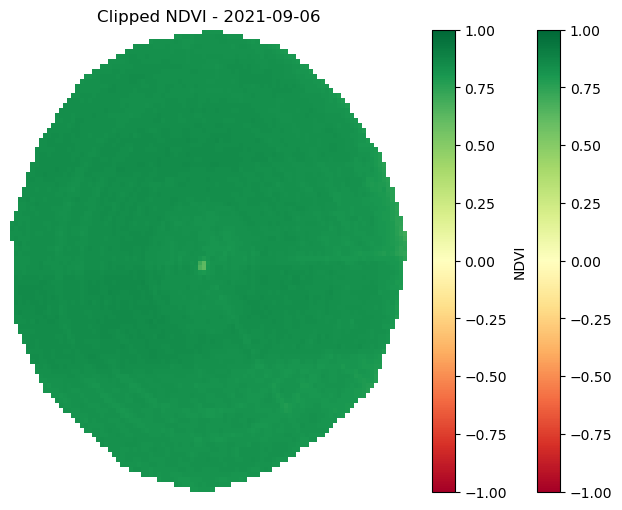


Processing image from 2021-09-01
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.8485


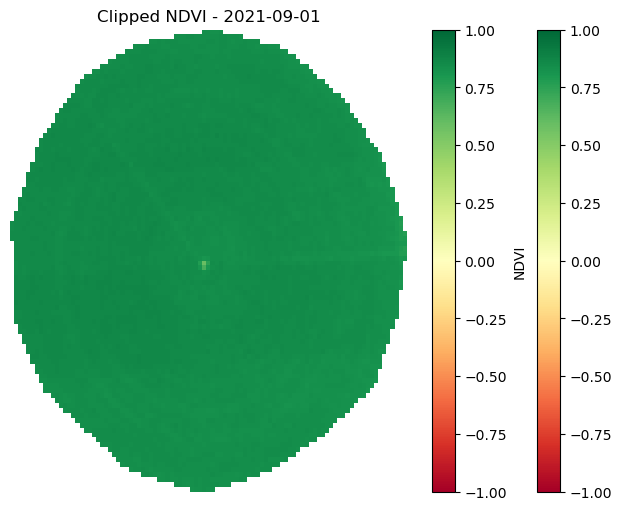


Processing image from 2021-08-22
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.8799


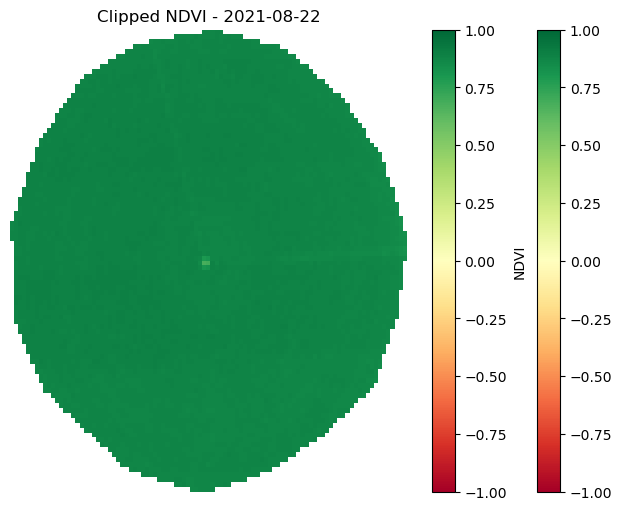


Processing image from 2021-08-17
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.8718


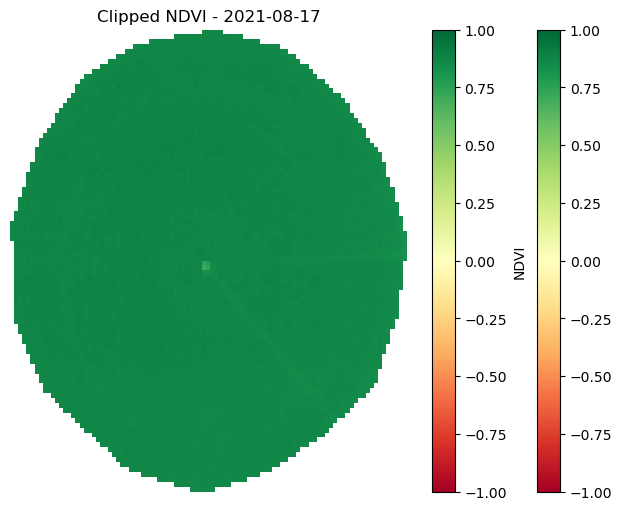


Processing image from 2021-08-12
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.8920


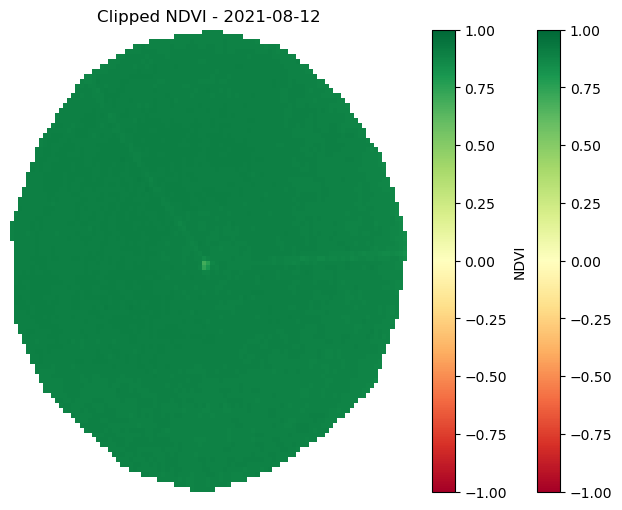


Processing image from 2021-07-28
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.9052


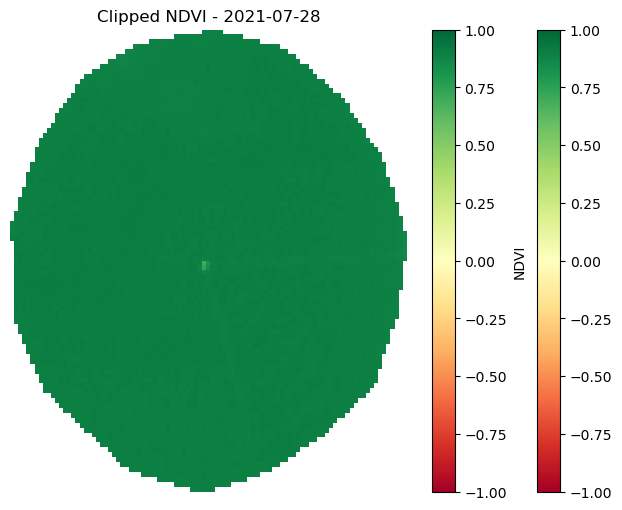


Processing image from 2021-07-18
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.9163


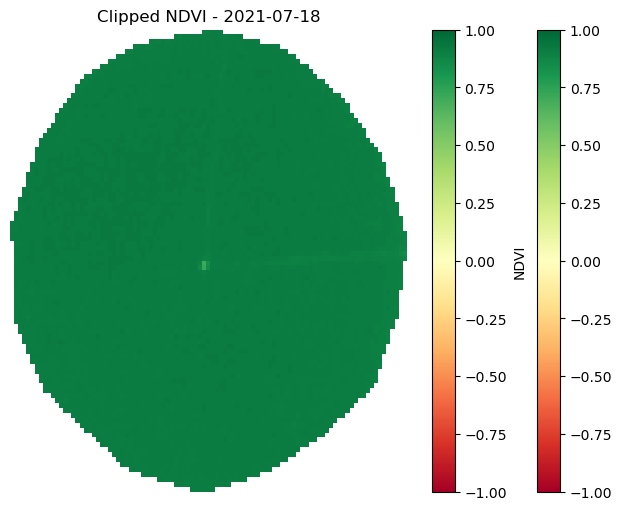


Processing image from 2021-07-13
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.9182


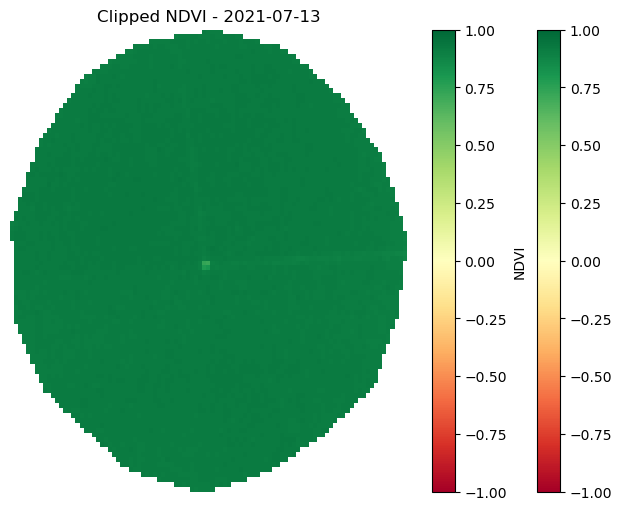


Processing image from 2021-07-08
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.9115


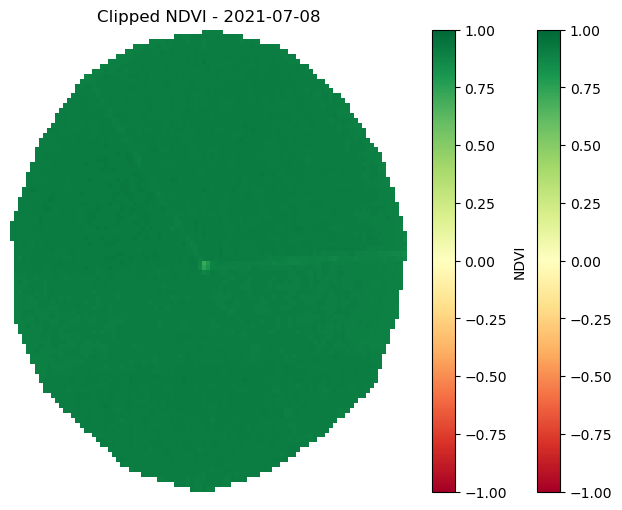


Processing image from 2021-06-28
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.9145


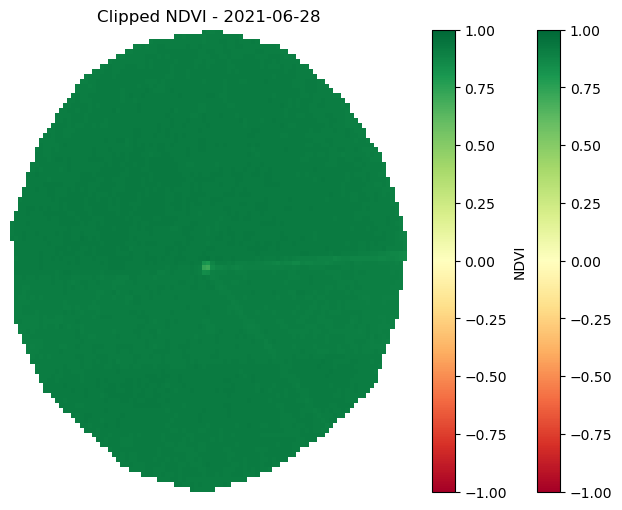


Processing image from 2021-06-18
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.8673


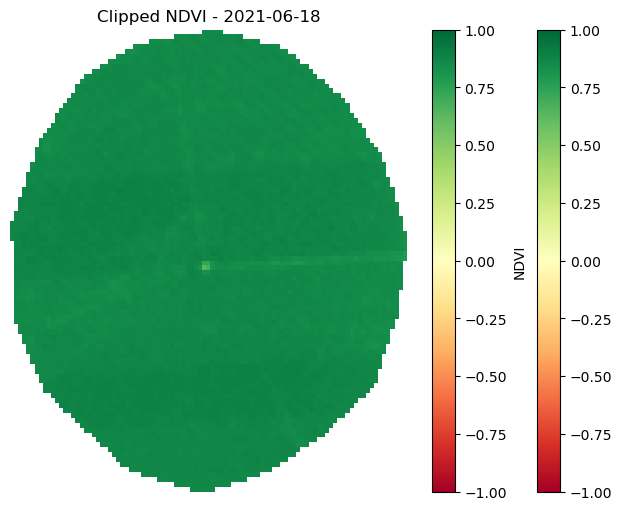


Processing image from 2021-06-08
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.6337


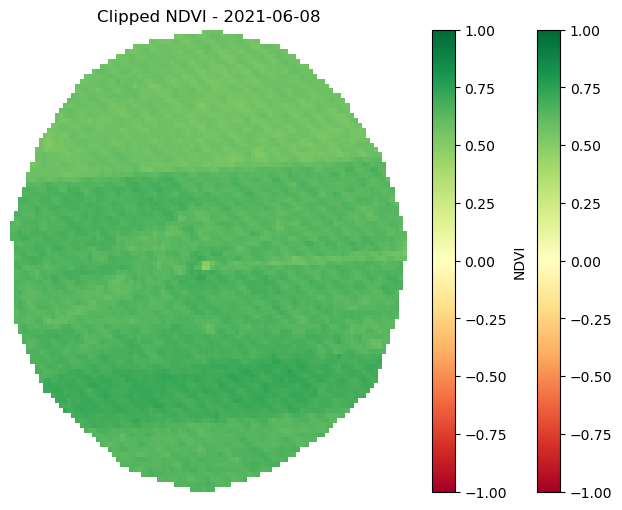


Processing image from 2021-06-03
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.4427


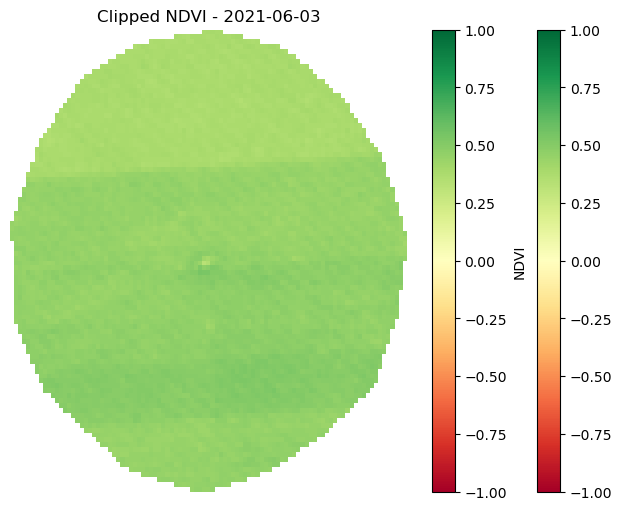


Processing image from 2021-05-19
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.1884


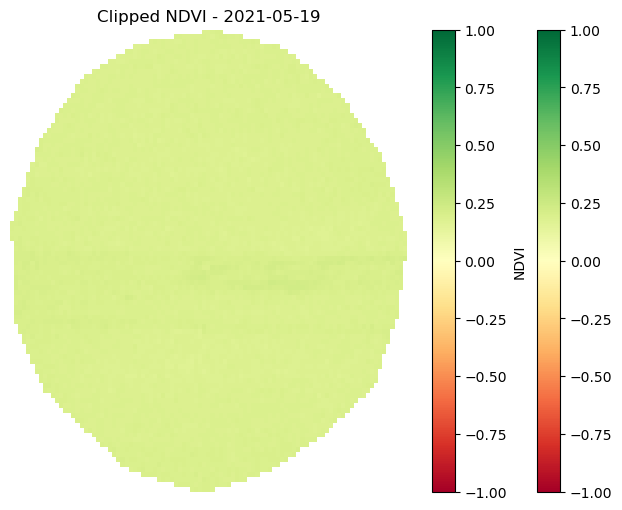


Processing image from 2021-05-14
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.1856


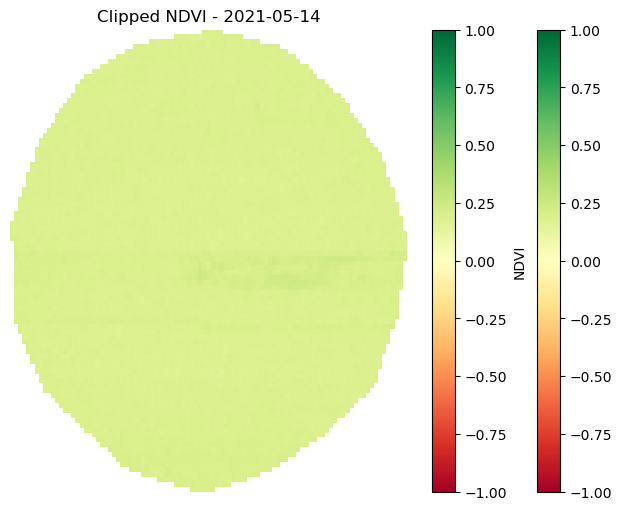


Processing image from 2021-05-09
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.1844


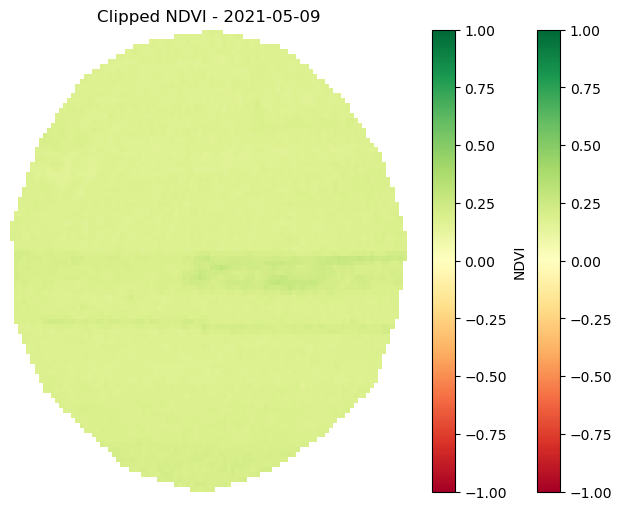


Processing image from 2021-05-04
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.1804


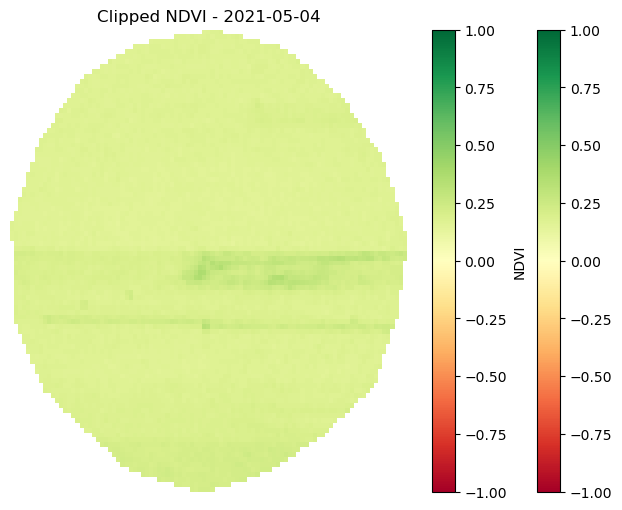


Processing image from 2021-04-29
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.1737


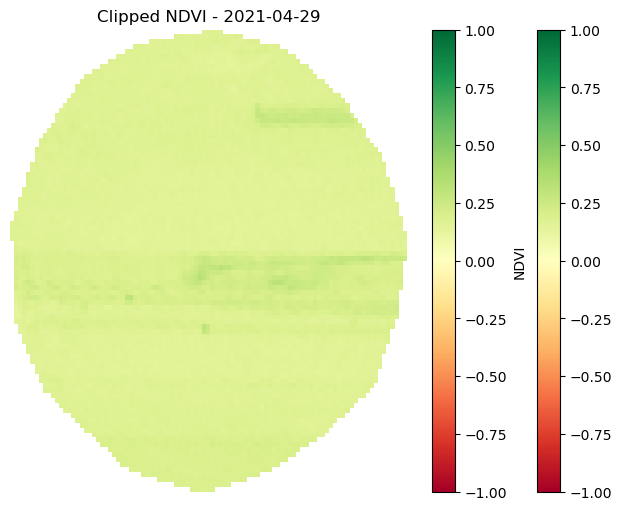


Processing image from 2021-03-30
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.8143


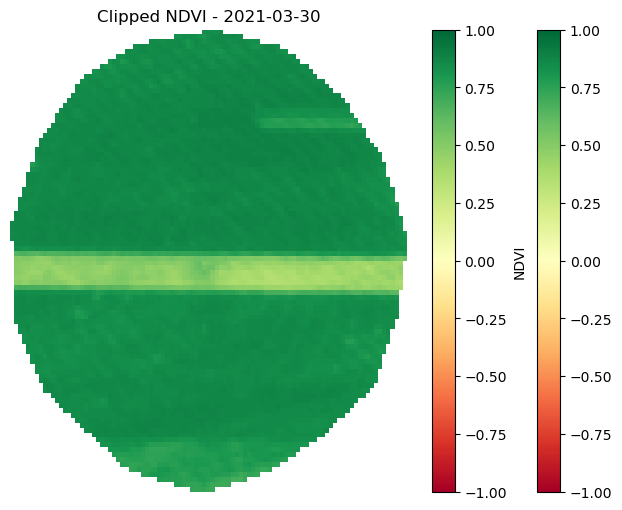


Processing image from 2021-03-05
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.9261


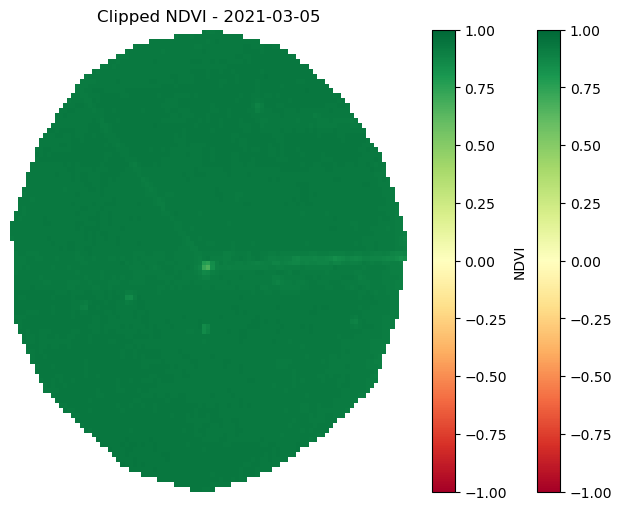


Processing image from 2021-01-24
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.6987


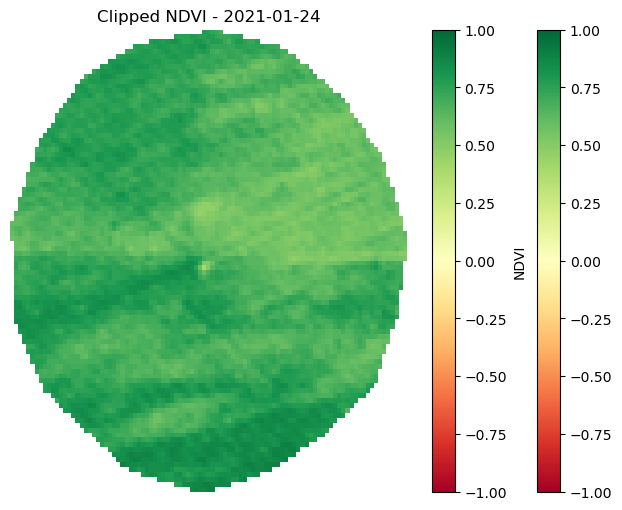


Processing image from 2021-01-19
Reprojecting geometry from EPSG:4326 to EPSG:32723
Starting clip...
Clip completed.
Mean NDVI: 0.6355


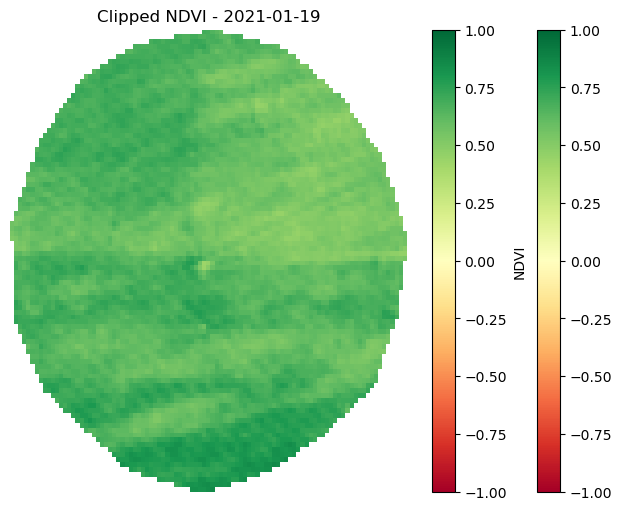

,date,mean_ndvi
0,2021-01-19,0.635511
1,2021-01-24,0.698652
2,2021-03-05,0.926099
3,2021-03-30,0.814258
4,2021-04-29,0.173651
5,2021-05-04,0.180434
6,2021-05-09,0.184388
7,2021-05-14,0.185613
8,2021-05-19,0.188416
9,2021-06-03,0.442658


In [4]:
# Connect to the catalog and search for Sentinel-2 images with less than 10% cloud cover
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# Modify the year to change date range
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=geometry,
    datetime="2021-01-01/2021-12-01",
    query={"eo:cloud_cover": {"lt": 10}},
    max_items=500
)

# List of items
items = list(search.get_items())
print(f"Images found: {len(items)}")

# Group items by date (format YYYY-MM-DD)
items_by_date = defaultdict(list)
for item in items:
    date_str = pd.to_datetime(item.datetime).date().isoformat()
    items_by_date[date_str].append(item)

# Select the item with the lowest cloud cover
filtered_items = []
for date_str, item_list in items_by_date.items():
    best_item = min(item_list, key=lambda x: x.properties["eo:cloud_cover"])
    filtered_items.append(planetary_computer.sign(best_item))

print(f"Unique images selected per date: {len(filtered_items)}")

# Filtered items processing
dates = []
ndvi_values = []

for item in filtered_items:
    try:
        date_fmt = pd.to_datetime(item.datetime).date()
        print(f"\nProcessing image from {date_fmt}")

        # Authenticated URLs of the bands
        red_url = item.assets["B04"].href
        nir_url = item.assets["B08"].href

        # Open bands with chunking
        red = rxr.open_rasterio(red_url, masked=True, chunks={"x": 512, "y": 512}).squeeze()
        nir = rxr.open_rasterio(nir_url, masked=True, chunks={"x": 512, "y": 512}).squeeze()

        # Reproject geometry if needed
        if gdf.crs != red.rio.crs:
            print(f"Reprojecting geometry from {gdf.crs} to {red.rio.crs}")
            project = pyproj.Transformer.from_crs(gdf.crs, red.rio.crs, always_xy=True).transform
            geoms_proj = [transform(project, geom) for geom in gdf.geometry]
        else:
            geoms_proj = list(gdf.geometry)

        # Clip the bands
        print("Starting clip...")
        red_clip = red.rio.clip(geoms_proj, red.rio.crs, drop=True)
        nir_clip = nir.rio.clip(geoms_proj, nir.rio.crs, drop=True)
        print("Clip completed.")

        # NDVI calculation
        ndvi = (nir_clip - red_clip) / (nir_clip + red_clip + 1e-6)
        mean_ndvi = float(ndvi.mean().values)
        print(f"Mean NDVI: {mean_ndvi:.4f}")

        dates.append(date_fmt)
        ndvi_values.append(mean_ndvi)

        # plot of clipped NDVI (OPTIONAL)
        plt.figure(figsize=(8,6))
        im = ndvi.plot(cmap='RdYlGn', vmin=-1, vmax=1)
        plt.title(f"Clipped NDVI - {date_fmt}")
        plt.colorbar(im, label='NDVI')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Processing error: {repr(e)}")

# Create the final DataFrame
ndvi_df = pd.DataFrame({"date": dates, "mean_ndvi": ndvi_values})
ndvi_df = ndvi_df.sort_values("date").reset_index(drop=True)

# Display the final series without duplicate dates
display(ndvi_df)

## NDVI Smoothing and Time Series Visualization

This block performs preprocessing, smoothing, and visualization of the NDVI time series based on a user-defined temporal window.

### 1. Data preparation
NDVI values are grouped by date and averaged to avoid duplicate observations.  
The date column is converted to datetime format and the dataset is optionally filtered according to a user-defined date range.

### 2. Temporal aggregation
Aggregation can be performed using either mean or median statistics.

### 3. NDVI interpolation and smoothing
Missing values are filled using linear interpolation to ensure temporal continuity.

The NDVI time series is then smoothed using one of the following methods:

- **Savitzky-Golay filter**: preserves local variations while reducing noise  
- **DMA3 (3-point moving average)**: simple short-window smoothing  
- **DMA5 (5-point moving average)**: stronger smoothing with reduced noise sensitivity  

The smoothing method is selected dynamically based on user input.

### 4. Visualization
Original NDVI values are plotted as scatter points, and the smoothed NDVI curve is overlaid to highlight temporal trends and vegetation dynamics.

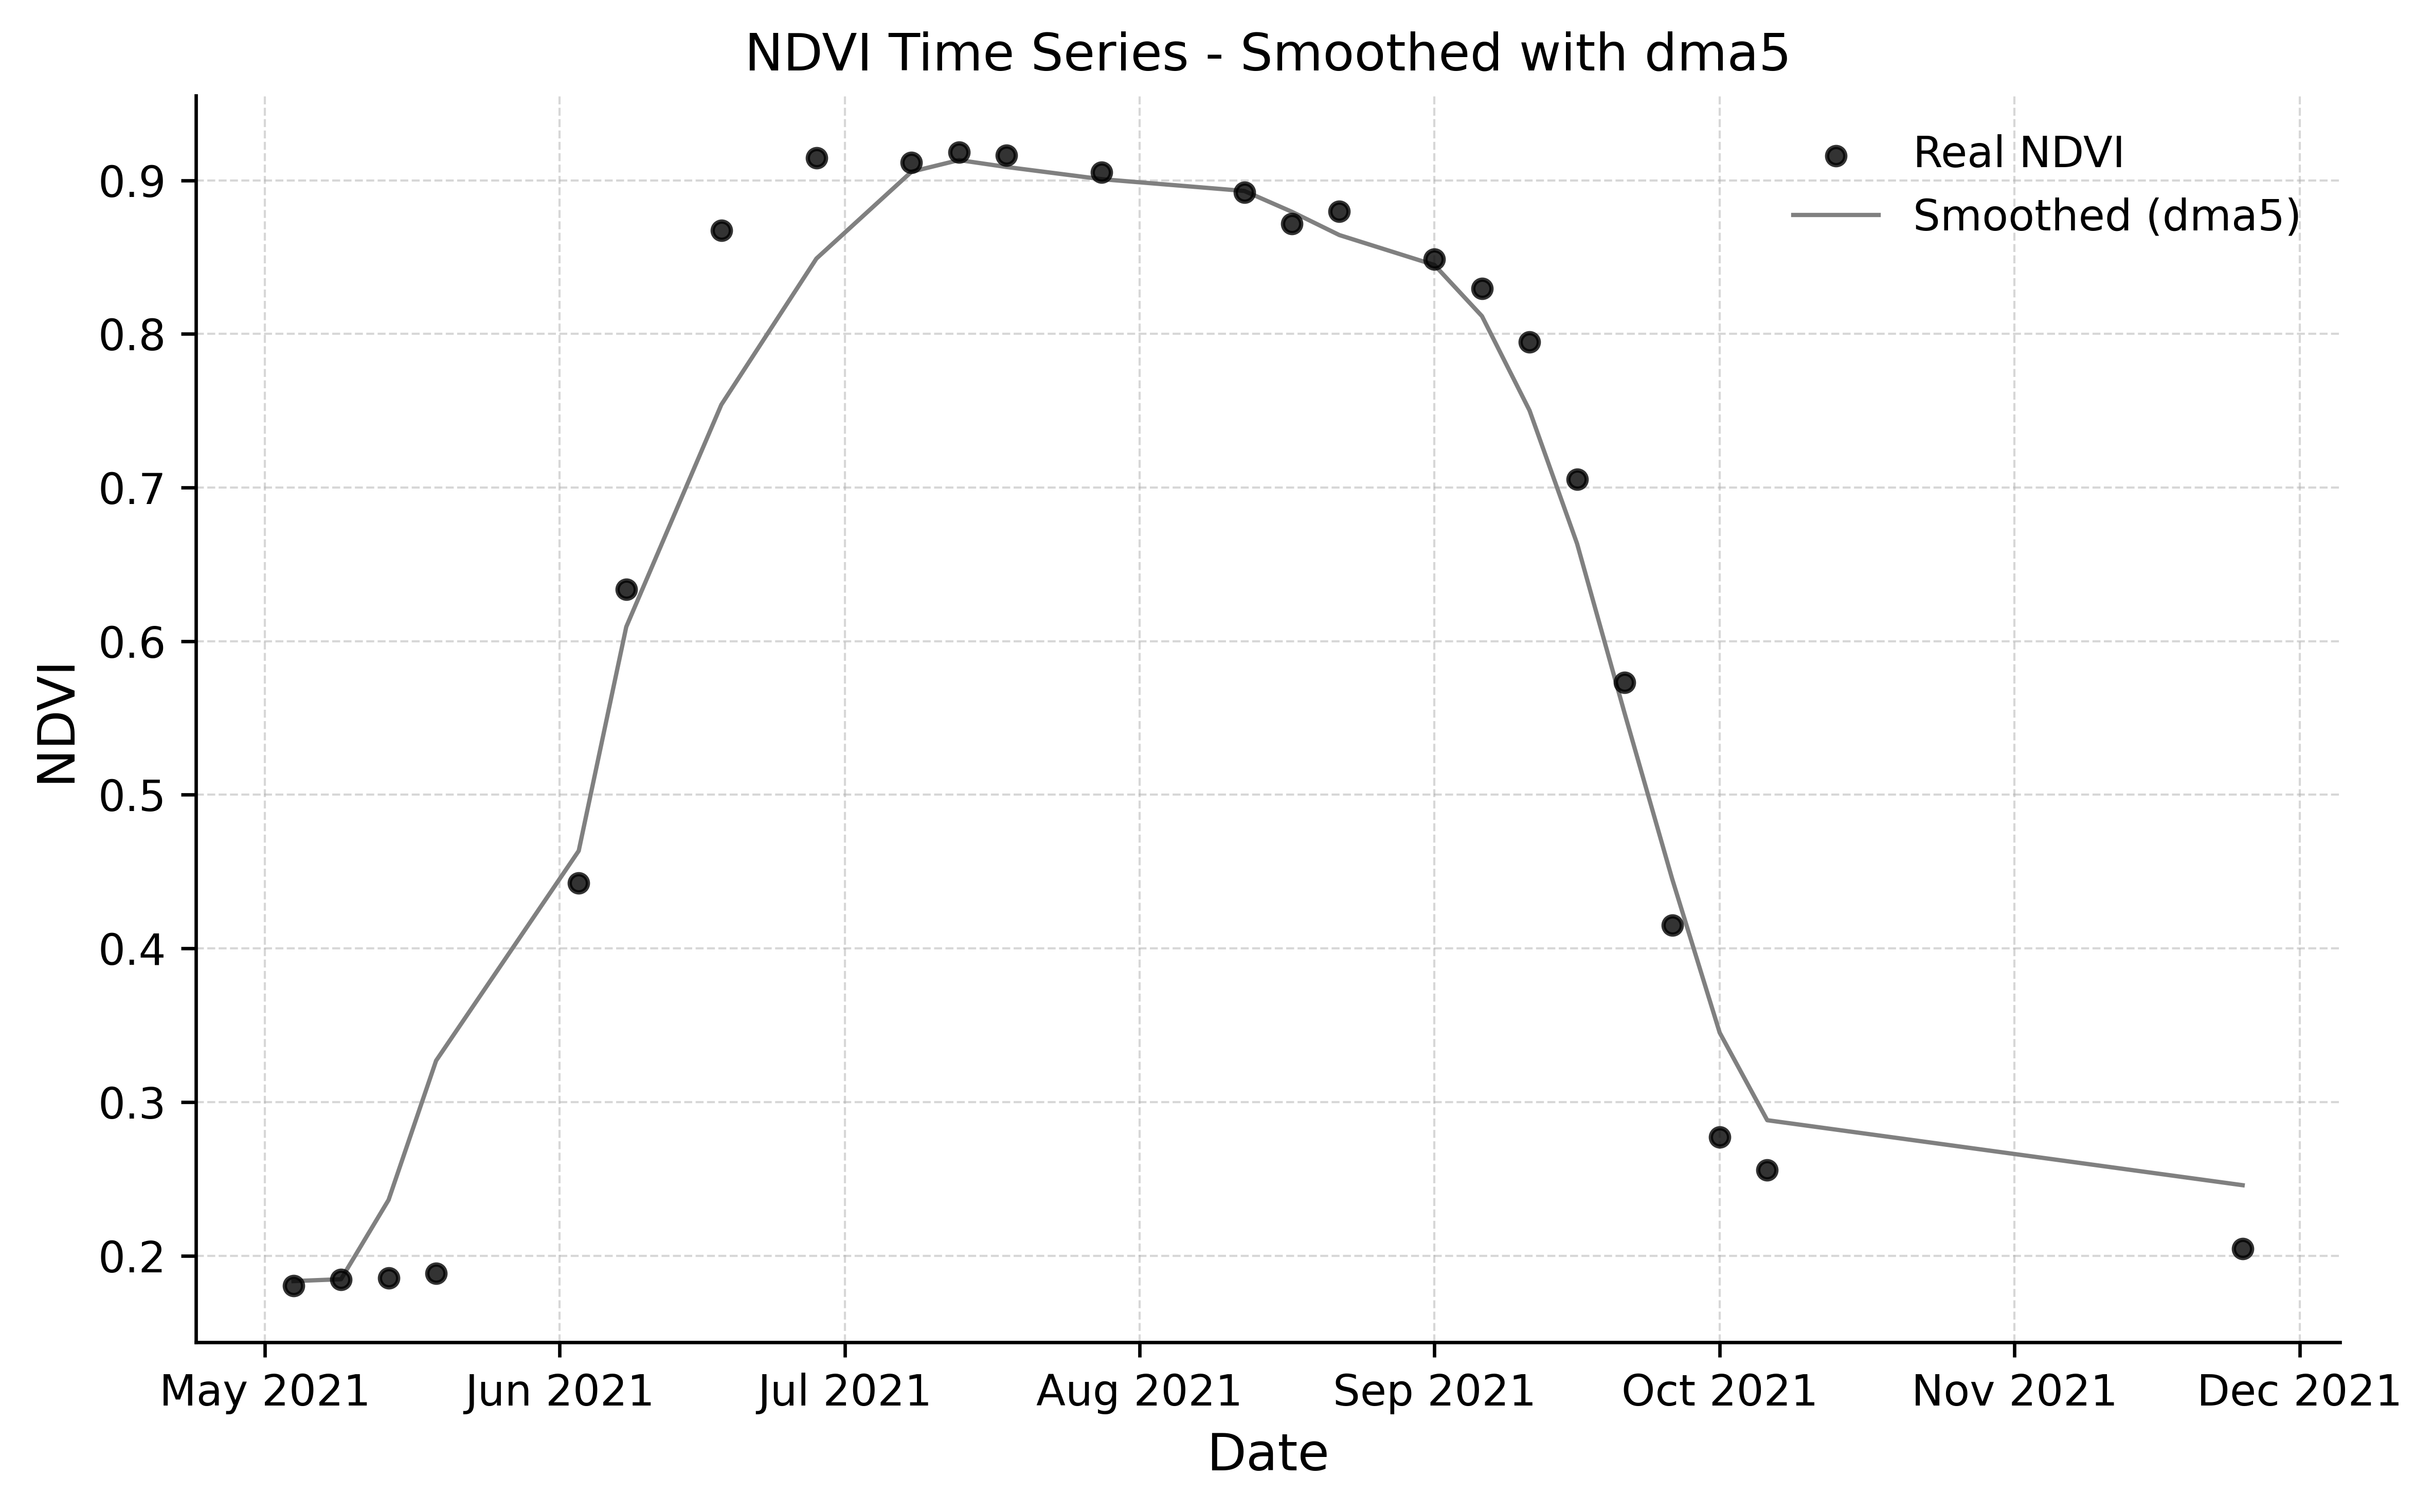

In [27]:
## SELECTION PARAMETERS
# Data range
start_date = "2021-05-01" # CHANGE
end_date = "2021-12-01" # CHANGE

# Aggregation and smoothing methods
ag = "median" # CHANGE HERE (mean or median)
sm = "dma5" # CHANGE HERE (dma3, dma5 or savgol)


# Data preparation
ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])

# Group by day and calculate mean NDVI (avoid duplicates)
ndvi_df_grouped = ndvi_df.groupby('date', as_index=False).mean()

# Garantir formato datetime
ndvi_df_grouped['date'] = pd.to_datetime(ndvi_df_grouped['date'])


# Smoothing function (interpolation + smoothing)

def smooth_and_plot(ndvi_df, label, start_date=None, end_date=None,
                    aggregation="mean", smoothing="savgol"):

    df = ndvi_df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # Data range filtering
    if start_date and end_date:
        df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

    # Preparing
    df = df.sort_values('date')
    df.set_index('date', inplace=True)

    # Resample (5 days)
    if aggregation == "mean":
        df = df.resample('5D').mean()
    elif aggregation == "median":
        df = df.resample('5D').median()
    else:
        raise ValueError("aggregation deve ser 'mean' ou 'median'")

    # Keep only real Sentinel-2 observations
    df = df.dropna(subset=['mean_ndvi'])
    
    real_dates = df.index
    real_ndvi = df['mean_ndvi']

    # Savitzky-Golay (savgol)
    n = len(df)
    poly_order = 2
    window_size = min(n if n % 2 == 1 else n - 1, 11)

    y = df['mean_ndvi'].values
    
    if smoothing == "savgol":
        n = len(y)
        poly_order = 2
        window_size = min(n if n % 2 == 1 else n - 1, 11)
    
        if window_size > poly_order:
            y_smooth = savgol_filter(y, window_size, poly_order)
        else:
            y_smooth = y
    
    elif smoothing == "dma3":
        y_smooth = pd.Series(y).rolling(3, center=True, min_periods=1).mean().values
    
    elif smoothing == "dma5":
        y_smooth = pd.Series(y).rolling(5, center=True, min_periods=1).mean().values
    
    else:
        raise ValueError("smoothing deve ser 'savgol', 'dma3' ou 'dma5'")
    
    df['smoothed_ndvi'] = y_smooth

    # Plot
    # Plot (versão melhorada)
    plt.figure(figsize=(8, 5), dpi=600)
    
    # Real Sentinel-2 observations
    plt.scatter(
        real_dates,
        real_ndvi,
        color="black",
        s=18,
        alpha=0.8,
        label="Real NDVI",
        zorder=5
    )
    
    plt.plot(
        df.index,
        df['smoothed_ndvi'],
        color="gray",
        linewidth=1,
        label=f"Smoothed ({smoothing})",
        zorder=3
    )
    
    plt.title(f"NDVI Time Series - {label}", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("NDVI", fontsize=12)
    
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.legend(frameon=False)
    
    plt.tight_layout()
    plt.show()

    df = df.reset_index()

    return df

start_month = pd.to_datetime(start_date).strftime("%B")
end_month = pd.to_datetime(end_date).strftime("%B")

label = f"Smoothed with {sm}"

ndvi_period = smooth_and_plot(
    ndvi_df_grouped,
    label,
    start_date=start_date,
    end_date=end_date,
    aggregation=ag,
    smoothing=sm
)

## Extraction and Visualization of Phenological Metrics from NDVI

This code block performs the extraction of phenological metrics from a smoothed NDVI time series and visualizes the results.

### 1. NDVI derivative computation
The smoothed NDVI time series is converted into a NumPy array, and its numerical derivative is computed to characterize vegetation growth and decline dynamics.

### 2. Phenological metrics extraction
A single-peak detection approach is applied to identify key phenological events based on NDVI values and derivative thresholds:

- **SOS (Start of Season):** First period of consistent NDVI increase over a minimum number of days  
- **POS (Peak of Season):** Date corresponding to the maximum NDVI value  
- **EOS (End of Season):** First stable decline phase after the peak, followed by stabilization  

Additionally, two quantitative descriptors are computed:
- **Amplitude (AMP):** Difference between peak NDVI and SOS NDVI  
- **Duration (DUR):** Time interval between SOS and EOS in days  

### 3. Metrics computation
The extraction function is applied to the smoothed NDVI time series to generate a dictionary containing all phenological metrics.

### 4. Results display
A formatted summary table is generated to display the extracted phenological metrics in a structured format.

### 5. Visualization
The NDVI time series is plotted, showing both raw (mean) and smoothed values.  
Key phenological points (SOS, POS, EOS) are highlighted with vertical markers to support interpretation of vegetation dynamics.

The final figure is exported in high resolution (600 DPI) for further analysis and reporting.

,Metrics,Values
0,SOS,2021-05-09
1,POS,2021-07-13
2,EOS,2021-11-25
3,AMP,0.728
4,DUR,200
5,MAX,0.913


Figure saved at 600 dpi: /Users/liviadias/phenoCrops/NDVI_May_to_November (median and dma5).png


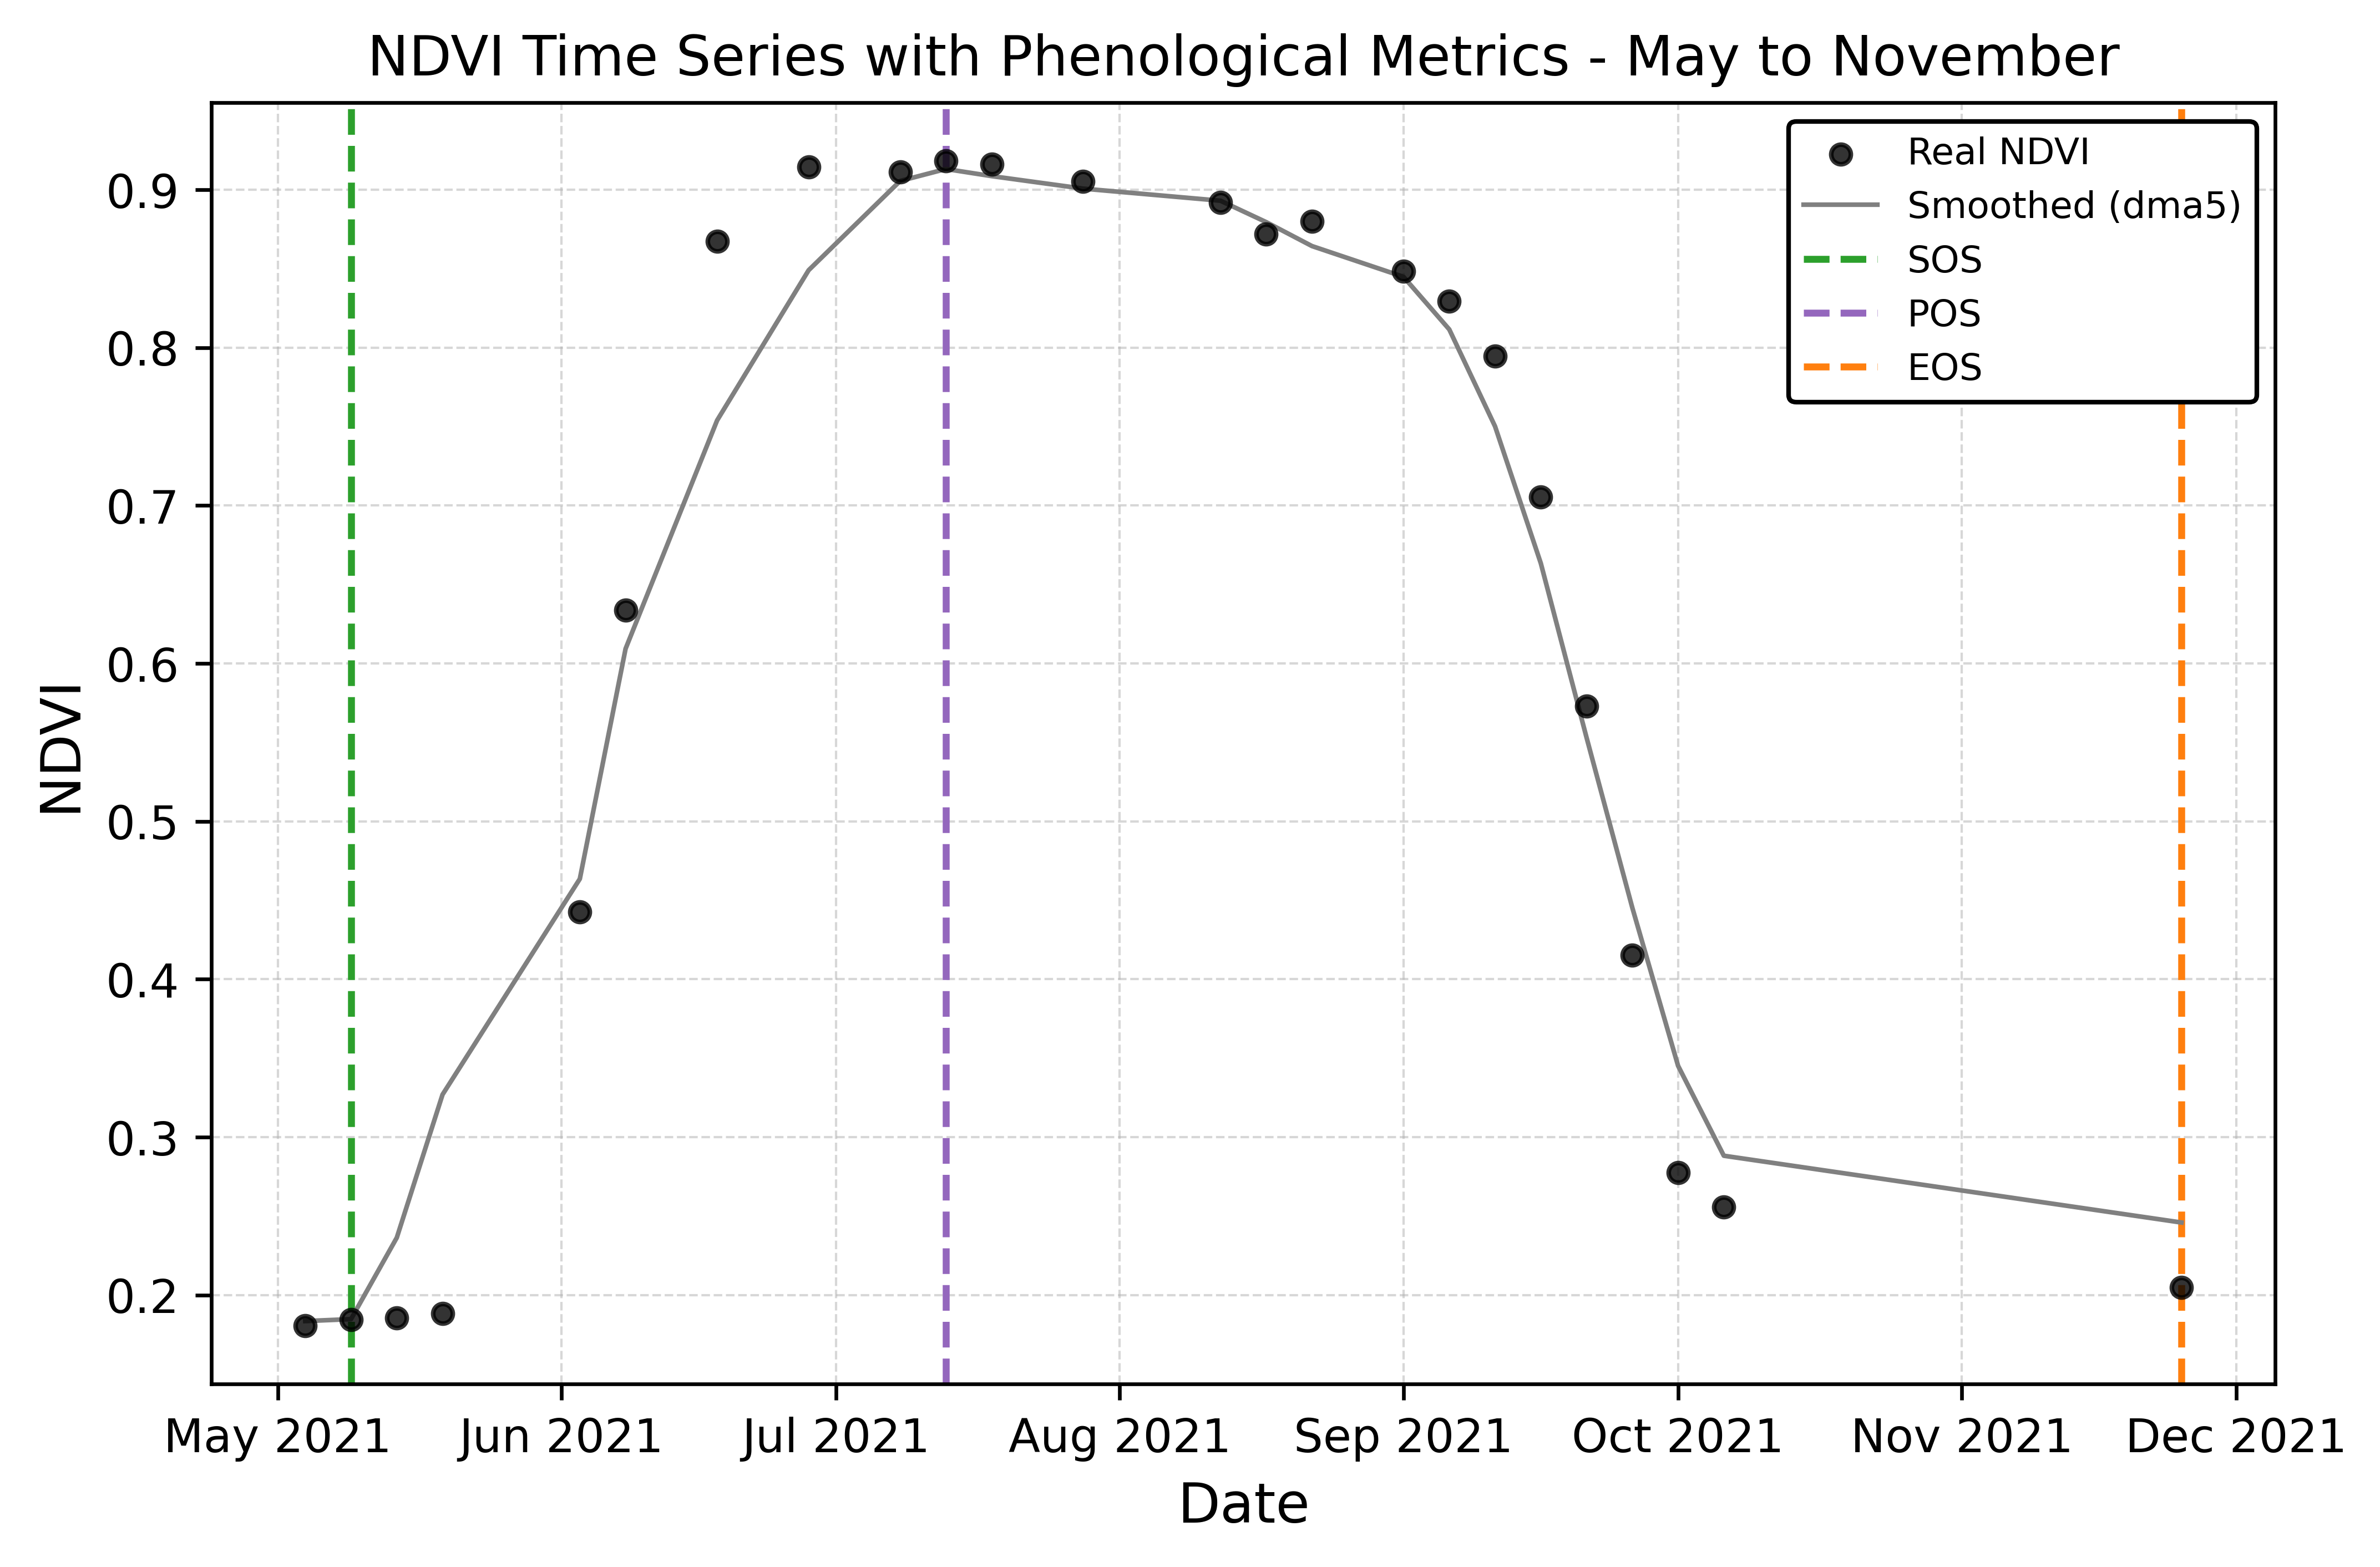

In [28]:
def extract_phenological_metrics_one_peak(dates, smoothed_ndvi,
                                          min_growth_days=3,
                                          min_decline_days=3,
                                          positive_deriv_threshold=0.002,
                                          negative_deriv_threshold=-0.005):

    df = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "ndvi": smoothed_ndvi
    }).sort_values("date").reset_index(drop=True)

    dates = df["date"]
    ndvi = df["ndvi"].values

    if len(ndvi) < 5:
        print("Series too short")
        return None

    derivative = np.gradient(ndvi)

    # POS
    pos_idx = np.argmax(ndvi)

    # SOS
    sos_idx = 0
    consecutive_growth = 0

    for i in range(pos_idx):
        if derivative[i] > positive_deriv_threshold:
            consecutive_growth += 1
            if consecutive_growth >= min_growth_days:
                sos_idx = max(0, i - min_growth_days + 1)
                break
        else:
            consecutive_growth = 0

    if sos_idx == 0:
        sos_idx = np.argmin(ndvi[:pos_idx]) if pos_idx > 0 else 0

    # EOS
    eos_idx = len(ndvi) - 1
    consecutive_decline = 0
    found_decline = False

    for i in range(pos_idx, len(ndvi)):
        if derivative[i] < negative_deriv_threshold:
            consecutive_decline += 1
            if consecutive_decline >= min_decline_days:
                found_decline = True

        if found_decline and derivative[i] >= 0:
            eos_idx = i
            break

    if eos_idx <= pos_idx:
        eos_idx = np.argmin(ndvi[pos_idx:]) + pos_idx

    # Phenological metrics
    sos = dates.iloc[sos_idx]
    pos = dates.iloc[pos_idx]
    eos = dates.iloc[eos_idx]

    amplitude = ndvi[pos_idx] - ndvi[sos_idx]
    duration_days = (eos - sos).days
    max_ndvi = np.max(ndvi)

    return {
        "SOS": sos,
        "POS": pos,
        "EOS": eos,
        "AMP": amplitude,
        "DUR": duration_days,
        "MAX": max_ndvi
    }
    
def show_metrics_and_plot(ndvi_subdf, label):

    ndvi_subdf = ndvi_subdf.copy()
    ndvi_subdf["date"] = pd.to_datetime(ndvi_subdf["date"])
    ndvi_subdf = ndvi_subdf.sort_values("date")

    # Remove NaN
    ndvi_subdf = ndvi_subdf.dropna(subset=["smoothed_ndvi"])

    # Metrics extraction
    metrics = extract_phenological_metrics_one_peak(
        ndvi_subdf["date"],
        ndvi_subdf["smoothed_ndvi"]
    )

    # Protection
    if metrics is None:
        print("Unable to extract metrics")
        return

    # Table
    metrics_df = pd.DataFrame({
        "Metrics": list(metrics.keys()),
        "Values": list(metrics.values())
    })

    def format_value(val):
        if isinstance(val, pd.Timestamp):
            return val.strftime("%Y-%m-%d")
        elif isinstance(val, float):
            return f"{val:.3f}"
        else:
            return val

    from IPython.display import display
    display(metrics_df.style.format({"Values": format_value})
            .set_caption(f"Phenological Metrics Summary - {label}"))

    # PLOT

    plt.figure(figsize=(8,5), dpi=600)
    
    # Real Sentinel-2 observations
    plt.scatter(
        ndvi_subdf["date"],
        ndvi_subdf["mean_ndvi"],
        color='black',
        s=18,
        alpha=0.8,
        label='Real NDVI',
        zorder=5
    )
    
    # Smoothed NDVI
    plt.plot(
        ndvi_subdf["date"],
        ndvi_subdf["smoothed_ndvi"],
        color='gray',
        linewidth=1,
        label=f"Smoothed ({sm})",
        zorder=3
    )
    
    # Phenological metrics
    plt.axvline(metrics["SOS"], color='#2ca02c', linestyle='--', linewidth=1.5, label='SOS')
    plt.axvline(metrics["POS"], color='#9467bd', linestyle='--', linewidth=1.5, label='POS')
    plt.axvline(metrics["EOS"], color='#ff7f0e', linestyle='--', linewidth=1.5, label='EOS')
    
    # Labels and titles
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("NDVI", fontsize=12)
    plt.title(f"NDVI Time Series with Phenological Metrics - {label}", fontsize=12)
    
    # Grid
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    
    ax = plt.gca()
    
    # x label (May 2021 etc.)
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    
    # Legend
    plt.legend(
        frameon=True,
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        loc='upper right',
        fontsize=8
    )
    # Downloading graphic
    safe_label = label.replace(" ", "_").replace("/", "-")
    output_path = os.path.join(os.getcwd(), f"NDVI_{safe_label} ({ag} and {sm}).png")

    plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')

    print(f"Figure saved at 600 dpi: {output_path}")
    
    plt.show()

start_month = ndvi_period["date"].min().strftime("%B")
end_month = ndvi_period["date"].max().strftime("%B")

label = f"{start_month} to {end_month}"

show_metrics_and_plot(ndvi_period, label)